# Experiment: KL-to-identity whitening — fixed lr_v/lr_b (real data, sub1 forearm staircase)

Applies the recommended fixed hyperparameters for `lr_alone=True` (`lr_v=2e-3` for forearm
contractions, `1e-3` for wrist; `lr_b=5e-3` for all contractions) to the real HD-EMG
recording used in `decomposition/notebooks/04.5_kl_to_identity_iter1.ipynb`
(`sub1`, `forearm`, `staircase_flx_1_thumb_15MVC`), with `wh_mode='kl_to_identity'`.
Follows the same structure as `sim_10_kl_to_cal_lr_fixed.ipynb`: no Optuna search here --
fixed, previously-recommended values applied directly, comparing two update rules that
share the same lr values (see `Config.lr_v`/`Config.lr_b`/`Config.lr_alone` docstrings),
each with and without `wh_b_coupling`. For the relative-error (`lr_alone=False`) update,
`lr_v` is halved relative to the `lr_alone=True` recommendation (`lr_b` unchanged),
mirroring the ratio `sim_10` used between its two update rules.

**Conditions compared**
| Condition | `lr_alone` | `wh_b_coupling` | Update rule |
|---|---|---|---|
| No adaptation | — | — | — |
| Relative error | `False` | `False` | step ∝ `lr_{v,b}` × direction-normalized gradient × signed error `e_v`/`e_b` |
| Relative error + coupling | `False` | `True` | as above, plus B gets the first-order V→B frame correction each batch |
| Learning rate only | `True` | `False` | step ∝ `lr_{v,b}` × raw natural gradient (no EMA direction-normalization, no error term) |
| Learning rate only + coupling | `True` | `True` | as above, plus B gets the first-order V→B frame correction each batch |

Unlike `sim_10`, this real recording has no ground-truth spike trains, so §10 (rate of
agreement) is replaced by a good-units-only coupling summary. The calibration
decomposition (whitening `V`, separation vectors `B`, spike/base centroids) comes from a
cached CBSS run on the first isometric phase (shared with the `decomposition` repo's own
notebooks) rather than `load_example`'s bundled calibration.


In [ ]:
import sys
from pathlib import Path

REPO        = Path('..', '..', '..').resolve()
DECOMP_REPO = (REPO / '..' / 'decomposition').resolve()
for _p in (str(REPO), str(DECOMP_REPO / 'src')):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from decomposition.loaders.loaders import load_all
from decomposition.cbss.cbss import CBSS
from decomposition.cbss.config import CBSSConfig
from decomposition.cbss.io import load_decomposition_result
from decomposition.signal.plots import plot_behaviour

from adapt_decomp.adaptation import AdaptDecomp
from adapt_decomp.config import Config
from adapt_decomp.utils import (
    rate_of_agreement_paired, rate_of_agreement,
    get_coefficient_of_variation, get_discharge_rate,
    get_pulse_to_noise_ratio, get_silhouette_measure,
    find_reliable_units,
)

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 100})


In [2]:
# ── Run control ──────────────────────────────────────────────────────────────
# Set RUN_DECOMP = False to reload saved results without re-running the decomposition.
RUN_DECOMP = True

EXP_NAME = 'kl_to_identity_lr_fixed'

TASK = 'staircase_flx_1_thumb_15MVC'
SUBJ = 'sub1'
LOC  = 'forearm'
BASE_NAME = f'{SUBJ}_{LOC}_{TASK}'

MAT_PATH     = DECOMP_REPO / 'data' / 'raw' / 'prepro_data_formatted' / LOC / SUBJ / f'{SUBJ}_{TASK}_prepro_data_{LOC}.mat'
DECOMP_CACHE = DECOMP_REPO / 'data' / 'processed' / 'decomp_full_from_iso0'  # cached CBSS calibration (iso0), one per subject/location

RESULTS_DIR = DECOMP_REPO / 'data' / 'processed' / 'adapt_opt_results' / BASE_NAME / EXP_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Results → {RESULTS_DIR}')


Results → C:\Users\Irene\Documents\work_local\decomposition\data\processed\adapt_opt_results\sub1_forearm_staircase_flx_1_thumb_15MVC\kl_to_identity_lr_fixed


## 1. Load data

In [3]:
data = load_all(MAT_PATH)

fs                = data['fs']
timestamps_np     = np.asarray(data['timestamps'])
phases            = data['phases']
n_samples, n_chs  = data['emg'].shape
ext_fact          = 1000 // n_chs
duration_s        = n_samples / fs

print(f'Channels: {n_chs}  |  Samples: {n_samples}  |  fs: {fs} Hz  |  Duration: {duration_s:.1f} s')
print(f'Extension factor: {ext_fact}  →  extended dim: {n_chs * ext_fact}')


Channels: 192  |  Samples: 134505  |  fs: 2048 Hz  |  Duration: 65.7 s
Extension factor: 5  →  extended dim: 960


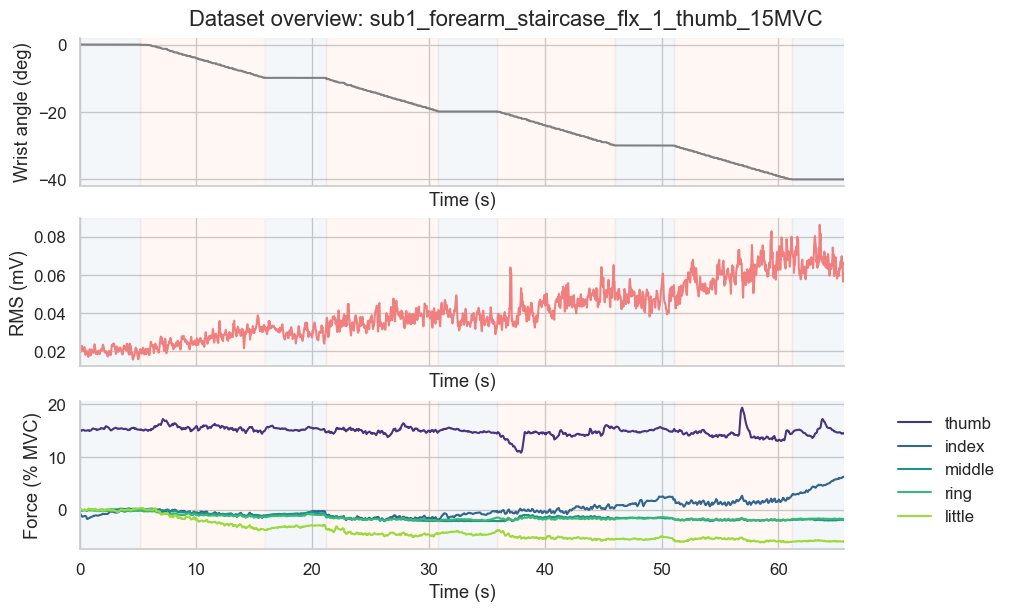

In [4]:
fig, axs = plot_behaviour(
    timestamps=data['timestamps'],
    rms=data['rms'],
    angle=data['angle'],
    force=data['force'],
    phases=data['phases'],
)
plt.suptitle(f'Dataset overview: {BASE_NAME}')
plt.show()


### Load static decomposition from iso0

The whitening matrix `V`, separation vectors `B`, and spike/base centroids come from a
CBSS decomposition of the first isometric phase (`iso0`), cached under
`decomp_full_from_iso0/{BASE_NAME}_iso_0` (produced by the same batch decomposition
pipeline as `decomposition/notebooks/04.5_kl_to_identity_iter1.ipynb`; recomputed from
scratch here only if the cache is missing). Units are filtered to the "good" subset
(SIL ≥ 0.9, DR ∈ [5,35] pps, CoV ≤ 35%, PNR ≥ 30 dB) on the calibration segment before
being handed to `AdaptDecomp`.


In [5]:
def load_or_run(name, run_fn):
    folder = DECOMP_CACHE / name
    try:
        result, saved_cfg = load_decomposition_result(folder)
        print(f'Loaded  {name}')
        return result, saved_cfg
    except FileNotFoundError:
        output = run_fn(save_path=DECOMP_CACHE, save_name=name)
        result, saved_cfg = output if isinstance(output, tuple) else (output, None)
        print(f'Saved   {name}')
        return result, saved_cfg


cfg_iso = CBSSConfig(
    fs=float(fs), preprocess_emg=False, ext_fact=ext_fact,
    n_components=None, sil_th=0.9, search_iter=500, ica_iter=200,
    spike_min_dist_ms=10, spike_det_exp=2.0, contrast_fun='smooth_abs',
    contrast_exp=3.0, random_seed=1909, device='cpu',
    compute_properties=True, verbose=False, min_spikes=10,
    ch_map=data['ch_map'],
)

iso      = phases['iso'][0, 0]
py_start = int(iso[0, 0]) - 1
py_end   = int(iso[0, 1])

iso_name = f'{BASE_NAME}_iso_0'
decomp_iso, _ = load_or_run(
    iso_name,
    lambda save_path, save_name: (
        CBSS(cfg_iso).decompose(
            data['emg'][py_start:py_end],
            timestamps=timestamps_np[py_start:py_end],
            save_path=save_path, save_name=save_name,
        ),
        cfg_iso,
    ),
)

# Calibration EMG/timestamps for the iso0 window -- read directly from `data` rather than
# decomp_iso.emg/.timestamps, since the cache under decomp_full_from_iso0 was written with
# save_emg=False.
emg_calib_seg = data['emg'][py_start:py_end]
ts_calib_seg  = timestamps_np[py_start:py_end]

sil  = get_silhouette_measure(decomp_iso.spikes, decomp_iso.sources, cfg_iso.ext_fact)
pnr  = get_pulse_to_noise_ratio(decomp_iso.spikes, decomp_iso.sources, cfg_iso.ext_fact)
dr   = get_discharge_rate(decomp_iso.spikes, ts_calib_seg, discard_isi=None)
cov  = get_coefficient_of_variation(decomp_iso.spikes, ts_calib_seg, discard_isi=None)
good = find_reliable_units(dr, cov, sil, pnr, dr_low_thr=5, dr_upp_thr=35,
                           cov_thr=0.35, sil_thr=0.9, pnr_thr=30)

total_units = decomp_iso.sources.shape[1]
n_units     = int(good.sum())
print(f'Total units from iso0: {total_units}  |  Good units: {n_units}')

whitening    = decomp_iso.whitening
sep_vectors  = decomp_iso.sep_vectors[:, good]
spikes_centr = decomp_iso.spikes_centr[good]
base_centr   = decomp_iso.base_centr[good]
sources_cal  = decomp_iso.sources[:, good]
spikes_cal   = decomp_iso.spikes[:, good]


Loaded  sub1_forearm_staircase_flx_1_thumb_15MVC_iso_0
Total units from iso0: 14  |  Good units: 10


In [6]:
def _make_inputs():
    return dict(
        emg             = torch.from_numpy(data['emg']).clone(),
        whitening       = torch.from_numpy(whitening).clone(),
        sep_vectors     = torch.from_numpy(sep_vectors.T).clone(),
        base_centr  = torch.from_numpy(base_centr).clone(),
        spikes_centr = torch.from_numpy(spikes_centr).clone(),
        emg_calib       = torch.from_numpy(emg_calib_seg).clone(),
        ipts_calib      = torch.from_numpy(sources_cal).clone(),
        spikes_calib    = torch.from_numpy(spikes_cal).clone(),
        preprocess      = False,
    )


### Recommended `lr_v`/`lr_b` values

`lr_alone=True` recommendation: `lr_v = 2e-3` for forearm contractions (`1e-3` for wrist),
`lr_b = 5e-3` for all contractions. For the `lr_alone=False` (relative-error) update,
`lr_v` is halved (`lr_b` unchanged), mirroring the ratio `sim_10` used between its two
update rules (`lr_v=3e-3` for relative-error vs. `7e-3` for learning-rate-only, same
`lr_b=3e-3`).

`safety_clip_multiplier_{v,b}` is left at the `Config` default (`20.0`) for all adaptive
conditions below. Raising it the way `sim_10` does for its own (larger) `lr_v` values
destabilized the whitening update on this real recording during testing -- the V-clip
rate jumped from ~0% to ~100% instead of dropping -- so the default trust-region ceiling
is kept throughout instead.


In [7]:
LR_V_LR_ALONE = {'forearm': 2e-3, 'wrist': 1e-3}[LOC]
LR_B_LR_ALONE = 1.e-3
LR_V_REL_ERR  = 1e-4
LR_B_REL_ERR  = 1.e-3   # same for lr_alone=True and lr_alone=False, all contraction types
SAFETY_CLIP   = 20.0   # Config default; see note above
MAX_ITER_B    = 1      # Max number of iterations for the optimisation of the separation vectors
print(f'LOC={LOC}: wh_learning_rate (lr_alone=True) = {LR_V_LR_ALONE:.1e}  |  '
      f'wh_learning_rate (lr_alone=False) = {LR_V_REL_ERR:.1e}  |  sv_learning_rate = {LR_B_REL_ERR:.1e}')


LOC=forearm: lr_v (lr_alone=True) = 2.0e-03  |  lr_v (lr_alone=False) = 1.0e-04  |  lr_b = 1.0e-03


## 2. No-adaptation baseline

All adaptation flags off. The calibration V and B are applied unchanged.

In [8]:
RUN_DECOMP = False
_out_no_path = RESULTS_DIR / 'out_no.pt'

if RUN_DECOMP:
    cfg_no = Config()
    cfg_no.ext_fact       = ext_fact
    cfg_no.adapt_wh       = False
    cfg_no.adapt_sv       = False
    cfg_no.adapt_sd       = False
    cfg_no.compute_loss       = True
    cfg_no.device         = 'cpu'
    cfg_no.wh_mode        = 'kl_to_identity'
    cfg_no.contrast_scope = 'spike_based'
    cfg_no.wh_b_coupling  = False

    out_no = AdaptDecomp(**_make_inputs(), config=cfg_no).run()
    torch.save(out_no, _out_no_path)
    print(f'Saved → {_out_no_path}')
else:
    out_no = torch.load(_out_no_path, weights_only=False)
    print(f'Loaded from {_out_no_path}')
print('No-adaptation run complete.')


Loaded from C:\Users\Irene\Documents\work_local\decomposition\data\processed\adapt_opt_results\sub1_forearm_staircase_flx_1_thumb_15MVC\kl_to_identity_lr_fixed\out_no.pt
No-adaptation run complete.


## 3. Relative error (`lr_alone=False`)

Direction-normalized natural gradient scaled by `lr_{v,b}` **and** the signed calibration
error `e_v`/`e_b`, so the step shrinks toward zero as the model converges to calibration
and grows for genuine drift.


In [9]:
RUN_DECOMP = True
_out_re_path = RESULTS_DIR / 'out_re.pt'

if RUN_DECOMP:
    cfg_re = Config()
    cfg_re.ext_fact       = ext_fact
    cfg_re.adapt_wh       = True
    cfg_re.adapt_sv       = True
    cfg_re.adapt_sd       = True
    cfg_re.compute_loss       = True
    cfg_re.device         = 'cpu'
    cfg_re.wh_mode        = 'kl_to_identity'
    cfg_re.contrast_scope = 'spike_based'
    cfg_re.wh_b_coupling  = False
    cfg_re.sv_epochs     = MAX_ITER_B
    cfg_re.wh_learning_rate           = LR_V_REL_ERR
    cfg_re.sv_learning_rate           = LR_B_REL_ERR
    cfg_re.lr_alone       = False
    cfg_re.debug          = True   # records per-batch delta_{V,B}_{raw_,}norm for §7 clip diagnostics
    cfg_re.safety_clip_multiplier_wh = SAFETY_CLIP
    cfg_re.safety_clip_multiplier_sv = SAFETY_CLIP

    out_re = AdaptDecomp(**_make_inputs(), config=cfg_re).run()
    torch.save(out_re, _out_re_path)
    print(f'Saved → {_out_re_path}')
else:
    out_re = torch.load(_out_re_path, weights_only=False)
    print(f'Loaded from {_out_re_path}')
print('Relative-error adaptation run complete.')


Saved → C:\Users\Irene\Documents\work_local\decomposition\data\processed\adapt_opt_results\sub1_forearm_staircase_flx_1_thumb_15MVC\kl_to_identity_lr_fixed\out_re.pt
Relative-error adaptation run complete.


### 3b. Relative error with V→B coupling (`wh_b_coupling=True`)

Same relative-error update as §3, but with `wh_b_coupling=True`: after each whitening (V)
step, the first-order frame correction implied by that step is propagated to B directly
(`B += B @ coupling_matrix`, see `adaptation.py::_update_V`), instead of letting B
discover the V-frame shift only indirectly through kappa drift over subsequent batches.


In [10]:
RUN_DECOMP = True
_out_re_c_path = RESULTS_DIR / 'out_re_coupled.pt'

if RUN_DECOMP:
    cfg_re_c = Config()
    cfg_re_c.ext_fact       = ext_fact
    cfg_re_c.adapt_wh       = True
    cfg_re_c.adapt_sv       = True
    cfg_re_c.adapt_sd       = True
    cfg_re_c.compute_loss       = True
    cfg_re_c.device         = 'cpu'
    cfg_re_c.wh_mode        = 'kl_to_identity'
    cfg_re_c.contrast_scope = 'spike_based'
    cfg_re_c.wh_b_coupling  = True
    cfg_re_c.sv_epochs     = MAX_ITER_B
    cfg_re_c.wh_learning_rate           = LR_V_REL_ERR
    cfg_re_c.sv_learning_rate           = LR_B_REL_ERR
    cfg_re_c.lr_alone       = False
    cfg_re_c.debug          = True   # records per-batch delta_{V,B}_{raw_,}norm for §7 clip diagnostics
    cfg_re_c.safety_clip_multiplier_wh = SAFETY_CLIP
    cfg_re_c.safety_clip_multiplier_sv = SAFETY_CLIP

    out_re_c = AdaptDecomp(**_make_inputs(), config=cfg_re_c).run()
    torch.save(out_re_c, _out_re_c_path)
    print(f'Saved → {_out_re_c_path}')
else:
    out_re_c = torch.load(_out_re_c_path, weights_only=False)
    print(f'Loaded from {_out_re_c_path}')
print('Relative-error + coupling adaptation run complete.')


Saved → C:\Users\Irene\Documents\work_local\decomposition\data\processed\adapt_opt_results\sub1_forearm_staircase_flx_1_thumb_15MVC\kl_to_identity_lr_fixed\out_re_coupled.pt
Relative-error + coupling adaptation run complete.


## 4. Learning rate only (`lr_alone=True`)

The signed error `e_v`/`e_b` is dropped entirely: `lr_{v,b}` alone sets a constant,
direction-normalized step applied every batch regardless of how close the model already
is to calibration -- the closest available reproduction of main (v1)'s fixed-learning-rate
update (see `Config.lr_alone`'s docstring). For B this also flips the update from
error-correcting descent to unconditional natural-gradient ascent on contrast.


In [11]:
RUN_DECOMP = True
_out_lo_path = RESULTS_DIR / 'out_lo.pt'

if RUN_DECOMP:
    cfg_lo = Config()
    cfg_lo.ext_fact       = ext_fact
    cfg_lo.adapt_wh       = True
    cfg_lo.adapt_sv       = True
    cfg_lo.adapt_sd       = True
    cfg_lo.compute_loss       = True
    cfg_lo.device         = 'cpu'
    cfg_lo.wh_mode        = 'kl_to_identity'
    cfg_lo.contrast_scope = 'spike_based'
    cfg_lo.wh_b_coupling  = False
    cfg_lo.sv_epochs     = MAX_ITER_B
    cfg_lo.wh_learning_rate           = LR_V_LR_ALONE
    cfg_lo.sv_learning_rate           = LR_B_LR_ALONE
    cfg_lo.lr_alone       = True
    cfg_lo.debug          = True   # records per-batch delta_{V,B}_{raw_,}norm for §7 clip diagnostics
    cfg_lo.safety_clip_multiplier_wh = SAFETY_CLIP
    cfg_lo.safety_clip_multiplier_sv = SAFETY_CLIP

    out_lo = AdaptDecomp(**_make_inputs(), config=cfg_lo).run()
    torch.save(out_lo, _out_lo_path)
    print(f'Saved → {_out_lo_path}')
else:
    out_lo = torch.load(_out_lo_path, weights_only=False)
    print(f'Loaded from {_out_lo_path}')
print('Learning-rate-only adaptation run complete.')


Saved → C:\Users\Irene\Documents\work_local\decomposition\data\processed\adapt_opt_results\sub1_forearm_staircase_flx_1_thumb_15MVC\kl_to_identity_lr_fixed\out_lo.pt
Learning-rate-only adaptation run complete.


### 4b. Learning rate only with V→B coupling (`wh_b_coupling=True`)

Same learning-rate-only update as §4, but with `wh_b_coupling=True` added on top.


In [12]:
RUN_DECOMP = True
_out_lo_c_path = RESULTS_DIR / 'out_lo_coupled.pt'

if RUN_DECOMP:
    cfg_lo_c = Config()
    cfg_lo_c.ext_fact       = ext_fact
    cfg_lo_c.adapt_wh       = True
    cfg_lo_c.adapt_sv       = True
    cfg_lo_c.adapt_sd       = True
    cfg_lo_c.compute_loss       = True
    cfg_lo_c.device         = 'cpu'
    cfg_lo_c.wh_mode        = 'kl_to_identity'
    cfg_lo_c.contrast_scope = 'spike_based'
    cfg_lo_c.wh_b_coupling  = True
    cfg_lo_c.sv_epochs     = MAX_ITER_B
    cfg_lo_c.wh_learning_rate           = LR_V_LR_ALONE
    cfg_lo_c.sv_learning_rate           = LR_B_LR_ALONE
    cfg_lo_c.lr_alone       = True
    cfg_lo_c.debug          = True   # records per-batch delta_{V,B}_{raw_,}norm for §7 clip diagnostics
    cfg_lo_c.safety_clip_multiplier_wh = SAFETY_CLIP
    cfg_lo_c.safety_clip_multiplier_sv = SAFETY_CLIP

    out_lo_c = AdaptDecomp(**_make_inputs(), config=cfg_lo_c).run()
    torch.save(out_lo_c, _out_lo_c_path)
    print(f'Saved → {_out_lo_c_path}')
else:
    out_lo_c = torch.load(_out_lo_c_path, weights_only=False)
    print(f'Loaded from {_out_lo_c_path}')
print('Learning-rate-only + coupling adaptation run complete.')


Saved → C:\Users\Irene\Documents\work_local\decomposition\data\processed\adapt_opt_results\sub1_forearm_staircase_flx_1_thumb_15MVC\kl_to_identity_lr_fixed\out_lo_coupled.pt
Learning-rate-only + coupling adaptation run complete.


## 5. Execution time per batch

In [13]:
cond_labels  = [
    'No adaptation',
    'Relative error', 'Relative error + coupling',
    'Learning rate only', 'Learning rate only + coupling',
]
cond_colors  = {
    'No adaptation':                 'tab:orange',
    'Relative error':                'tab:blue',
    'Relative error + coupling':     'tab:cyan',
    'Learning rate only':            'tab:green',
    'Learning rate only + coupling': 'tab:red',
}
cond_outputs = {
    'No adaptation':                 out_no,
    'Relative error':                out_re,
    'Relative error + coupling':     out_re_c,
    'Learning rate only':            out_lo,
    'Learning rate only + coupling': out_lo_c,
}


In [14]:
for label in cond_labels:
    out = cond_outputs[label]
    print(label)
    print('-' * len(label))
    for key in ['wh_time_ms', 'sv_time_ms', 'sd_time_ms', 'total_time_ms']:
        print(f'  {key:>15}: {out[key].mean():.3f} ± {out[key].std():.3f} ms')
    print()


No adaptation
-------------
       wh_time_ms: 18.378 ± 10.016 ms
       sv_time_ms: 0.155 ± 0.435 ms
       sd_time_ms: 0.542 ± 0.582 ms
    total_time_ms: 19.075 ± 10.070 ms

Relative error
--------------
       wh_time_ms: 17.020 ± 3.825 ms
       sv_time_ms: 0.698 ± 2.118 ms
       sd_time_ms: 0.256 ± 1.230 ms
    total_time_ms: 17.975 ± 3.830 ms

Relative error + coupling
-------------------------
       wh_time_ms: 17.585 ± 4.060 ms
       sv_time_ms: 0.621 ± 2.259 ms
       sd_time_ms: 0.307 ± 1.475 ms
    total_time_ms: 18.513 ± 4.304 ms

Learning rate only
------------------
       wh_time_ms: 17.492 ± 7.916 ms
       sv_time_ms: 0.971 ± 3.123 ms
       sd_time_ms: 0.238 ± 1.334 ms
    total_time_ms: 18.701 ± 8.092 ms

Learning rate only + coupling
-----------------------------
       wh_time_ms: 17.061 ± 4.374 ms
       sv_time_ms: 1.142 ± 3.221 ms
       sd_time_ms: 0.443 ± 1.995 ms
    total_time_ms: 18.645 ± 4.900 ms



## 6. Loss trajectories

- **wh_loss**: KL divergence between online and calibration whitened covariance
- **sv_loss**: squared contrast error per source
- **centroid_loss**: squared centroid deviation per source (logged for monitoring)

Values near zero mean the online statistics match calibration.


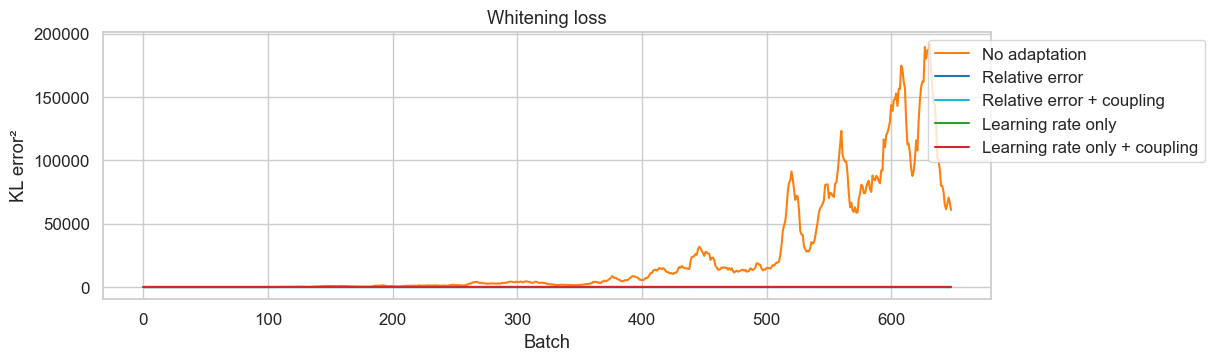

In [15]:
fig, ax = plt.subplots(figsize=(12, 3.5), layout='constrained')
for label in cond_labels:
    ax.plot(cond_outputs[label]['wh_loss'][10:-1], label=label, color=cond_colors[label])
ax.set(xlabel='Batch', ylabel='KL error²', title='Whitening loss')
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()


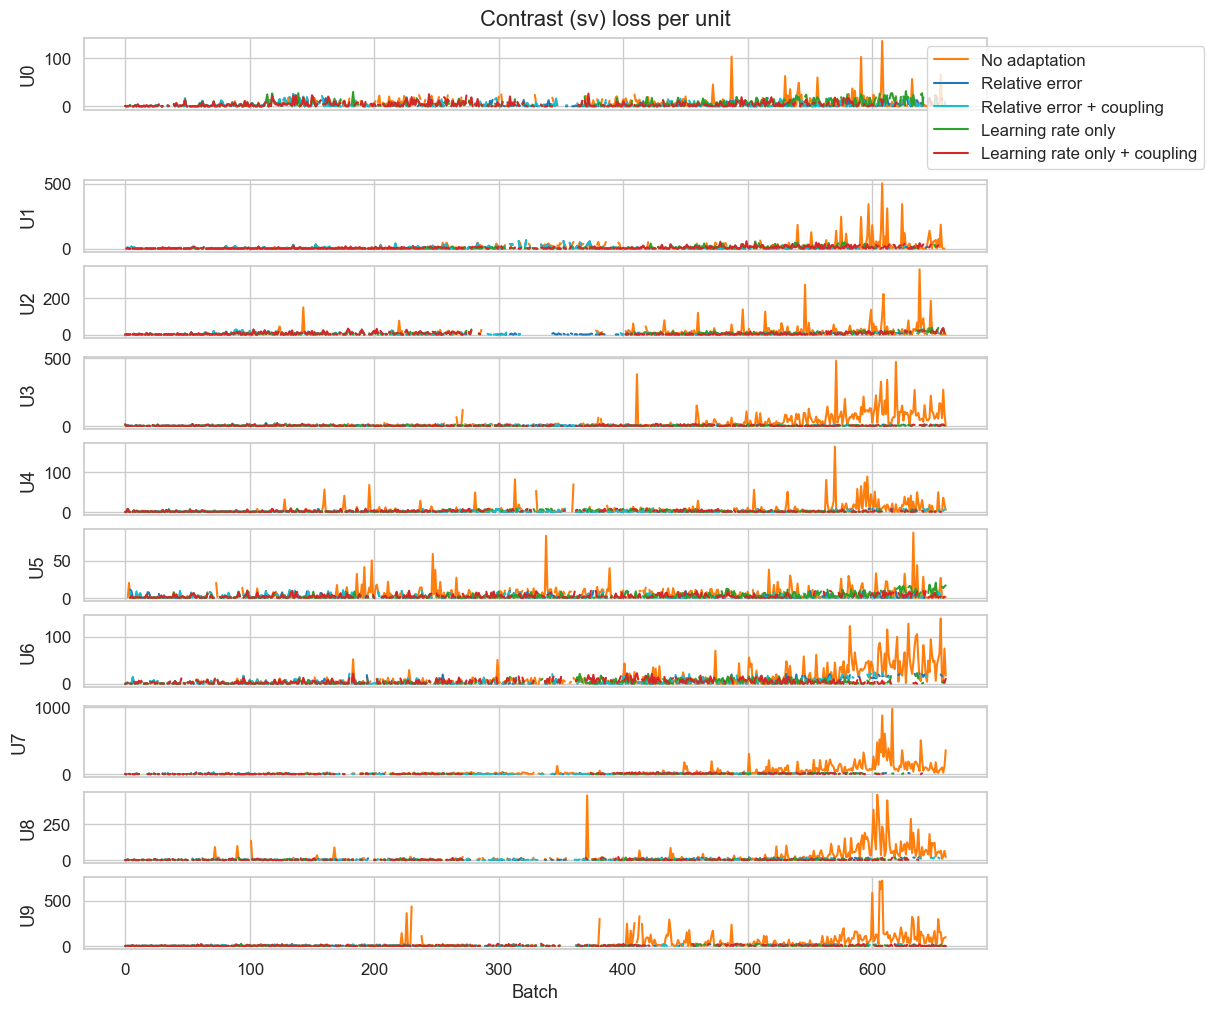

In [16]:
fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        axs[u].plot(cond_outputs[label]['sv_loss'][:, u], label=label, color=cond_colors[label])
    axs[u].set(ylabel=f'U{u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Batch')
plt.suptitle('Contrast (sv) loss per unit')
plt.show()


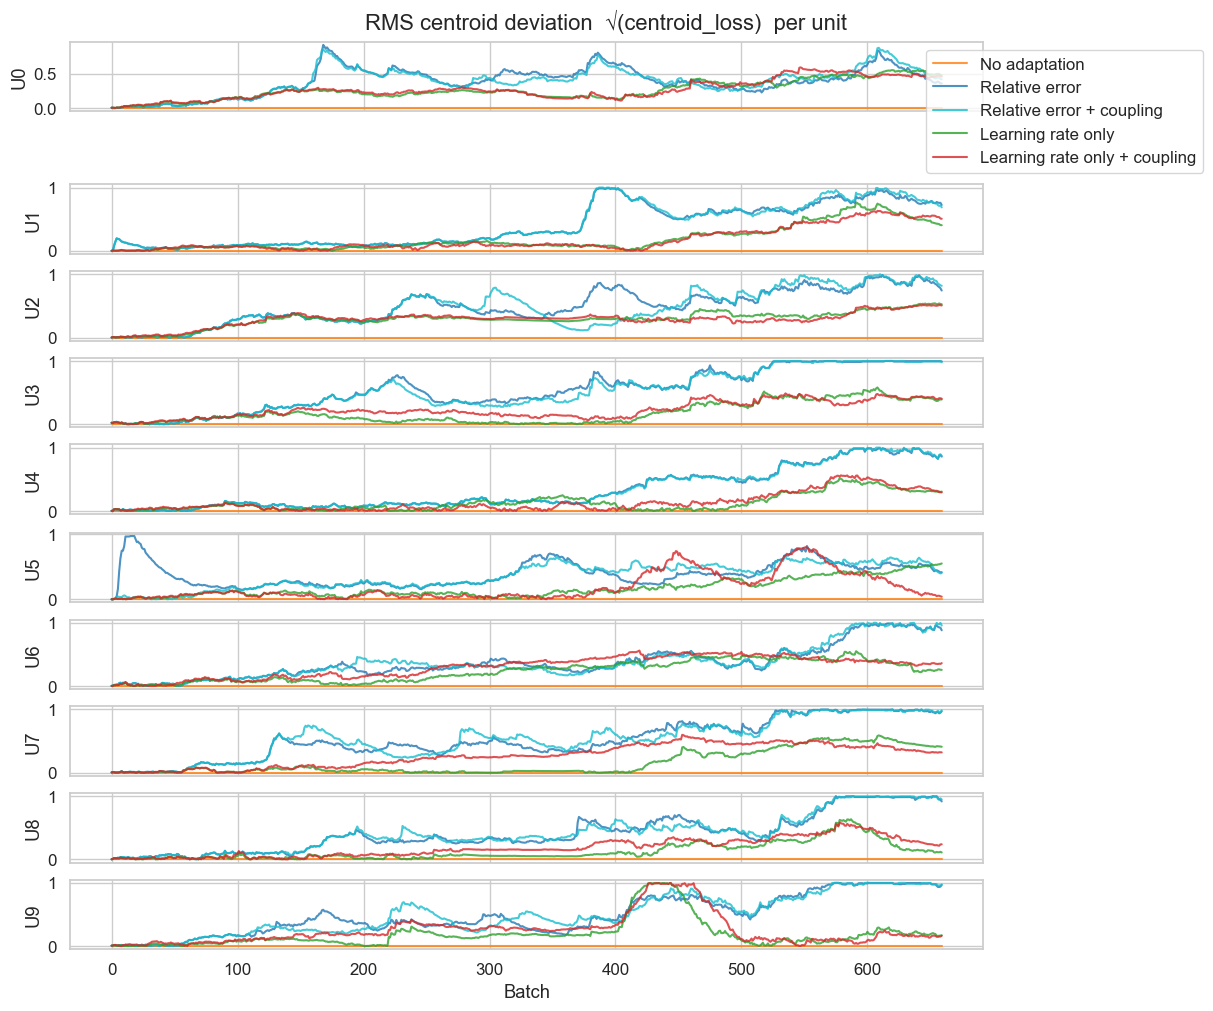

In [17]:
fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        out = cond_outputs[label]
        if 'centroid_loss' in out:
            axs[u].plot(
                np.sqrt(out['centroid_loss'][:, u].numpy()),
                label=label, color=cond_colors[label], alpha=0.8,
            )
    axs[u].set(ylabel=f'U{u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Batch')
plt.suptitle('RMS centroid deviation  √(centroid_loss)  per unit')
plt.show()


## 7. Clipping diagnostics

How often does the safety-net trust-region clip (`safety_clip_multiplier_{v,b} * lr_{v,b}`)
actually engage, versus the direction-normalized step being applied at its full,
unclipped size? Ratio = `‖Δ_applied‖ / ‖Δ_target‖`: 1.0 means the natural-gradient step
went through unchanged; below 1.0 means the clip capped it that batch. Requires
`cfg.debug=True` (set in the Relative-error / Learning-rate-only config cells above),
which records per-batch `delta_{V,B}_{raw_,}norm`. No-adaptation is excluded -- it never
takes a V/B step, so there's nothing to clip.


In [18]:
def _clip_ratios(diagnostics, n_units, tol=1e-6):
    '''Per-batch ratio of applied delta-norm to pre-clip target norm.

    ratio == 1  -> step applied unchanged (clip inactive that batch)
    ratio <  1  -> the safety-net trust-region clip capped the step
    V is scalar (one whitening update per batch); B is per-unit ([n_units]).
    '''
    idxs    = sorted(diagnostics.keys())
    v_ratio = np.full(len(idxs), np.nan)
    b_ratio = np.full((len(idxs), n_units), np.nan)
    for row, i in enumerate(idxs):
        d = diagnostics[i]
        if 'delta_wh_raw_norm' in d and d['delta_wh_raw_norm'] > tol:
            v_ratio[row] = d['delta_wh_norm'] / d['delta_wh_raw_norm']
        if 'delta_sv_raw_norm' in d:
            raw, norm = d['delta_sv_raw_norm'].numpy(), d['delta_sv_norm'].numpy()
            valid = raw > tol
            b_ratio[row, valid] = norm[valid] / raw[valid]
    return np.array(idxs), v_ratio, b_ratio


clip_conditions = [
    'Relative error', 'Relative error + coupling',
    'Learning rate only', 'Learning rate only + coupling',
]
clip_diag = {}
for label in clip_conditions:
    batches, v_ratio, b_ratio = _clip_ratios(cond_outputs[label]['diagnostics'], n_units)
    clip_diag[label] = {'batches': batches, 'v_ratio': v_ratio, 'b_ratio': b_ratio}

    v_clipped_pct = np.nanmean(v_ratio < 1 - 1e-6) * 100
    b_clipped_pct = np.nanmean(b_ratio  < 1 - 1e-6) * 100
    print(f'{label:>30}: V clipped in {v_clipped_pct:5.1f}% of batches  |  '
          f'B clipped in {b_clipped_pct:5.1f}% of (batch, unit) pairs')


                Relative error: V clipped in   0.0% of batches  |  B clipped in   0.1% of (batch, unit) pairs
     Relative error + coupling: V clipped in   0.0% of batches  |  B clipped in   0.2% of (batch, unit) pairs
            Learning rate only: V clipped in   0.3% of batches  |  B clipped in  79.3% of (batch, unit) pairs
 Learning rate only + coupling: V clipped in   0.3% of batches  |  B clipped in  76.2% of (batch, unit) pairs


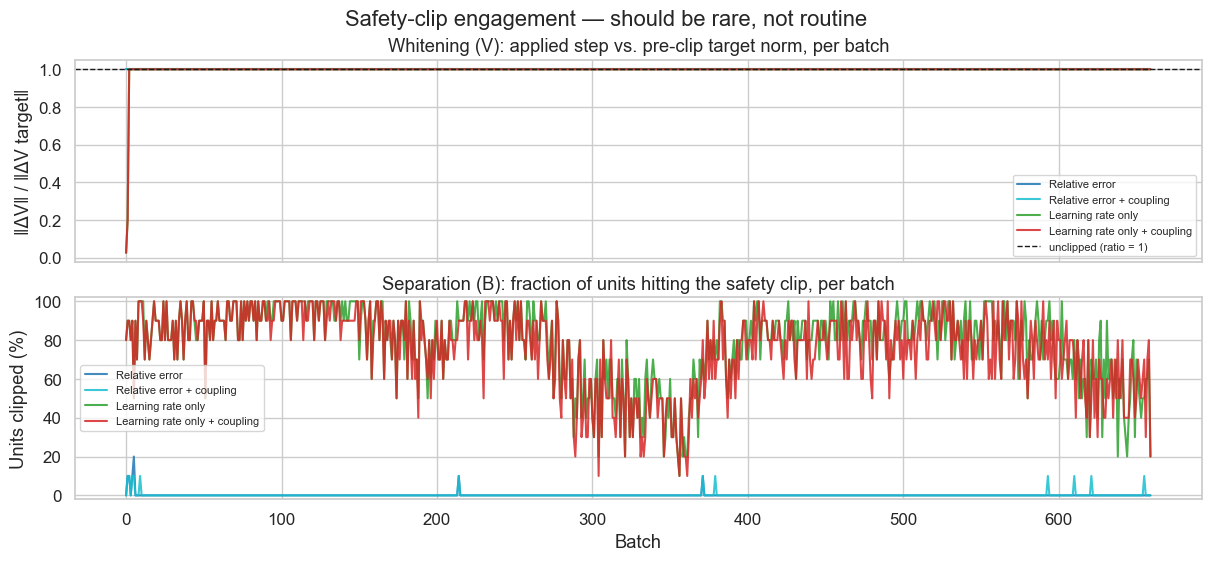

In [19]:
fig, (ax_v, ax_b) = plt.subplots(2, 1, figsize=(12, 5.5), layout='constrained', sharex=True)

for label in clip_conditions:
    cd = clip_diag[label]
    ax_v.plot(cd['batches'], cd['v_ratio'], label=label, color=cond_colors[label], alpha=0.85)
ax_v.axhline(1.0, color='k', linestyle='--', linewidth=1, label='unclipped (ratio = 1)')
ax_v.set(ylabel='‖ΔV‖ / ‖ΔV target‖',
         title='Whitening (V): applied step vs. pre-clip target norm, per batch')
ax_v.legend(fontsize=8, loc='lower right')

for label in clip_conditions:
    cd = clip_diag[label]
    frac_clipped = np.nanmean(cd['b_ratio'] < 1 - 1e-6, axis=1) * 100
    ax_b.plot(cd['batches'], frac_clipped, label=label, color=cond_colors[label], alpha=0.85)
ax_b.set(xlabel='Batch', ylabel='Units clipped (%)', ylim=(-2, 102),
         title='Separation (B): fraction of units hitting the safety clip, per batch')
ax_b.legend(fontsize=8)

plt.suptitle('Safety-clip engagement — should be rare, not routine')
plt.show()


## 8. IPTs and spike trains

Squared IPTs with detected spike times overlaid.

In [20]:
cond_labels

['No adaptation',
 'Relative error',
 'Relative error + coupling',
 'Learning rate only',
 'Learning rate only + coupling']

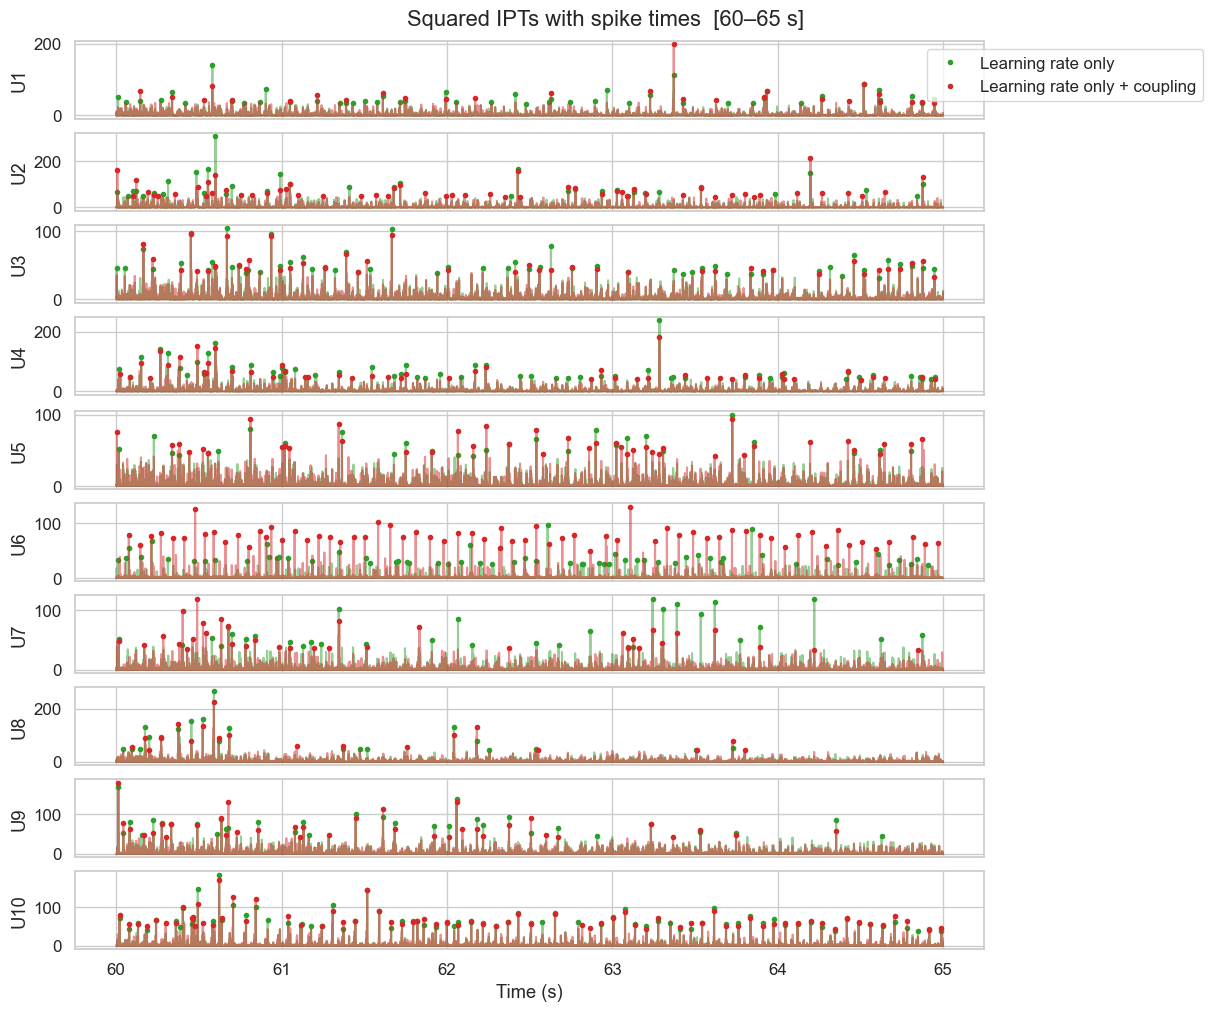

In [21]:
# t0, t1 = 0, int(duration_s)
t0, t1 = 60, 65
idxs   = np.arange(int(t0 * fs), int(t1 * fs))

fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    # for label in cond_labels:
    for label in ['Learning rate only','Learning rate only + coupling', ]:
        out     = cond_outputs[label]
        ipts_sq = out['ipts'][idxs, u].numpy() ** 2
        axs[u].plot(timestamps_np[idxs], ipts_sq, color=cond_colors[label], alpha=0.5)
        smask = out['spikes'][idxs, u].to(bool)
        axs[u].plot(
            timestamps_np[idxs][smask], ipts_sq[smask],
            linestyle='None', marker='.', color=cond_colors[label],
            label=label if u == 0 else None,
        )
    axs[u].set(ylabel=f'U{u + 1}')
axs[0].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Time (s)')
plt.suptitle(f'Squared IPTs with spike times  [{t0}–{t1} s]')
plt.show()


## 9. Decomposition quality metrics

A unit is **good** if SIL ≥ 0.9, DR ∈ [5, 35] pps.

In [22]:
rows = []
for label in cond_labels:
    out       = cond_outputs[label]
    spikes_np = out['spikes'].numpy().astype(float)
    ipts_np   = out['ipts'].numpy()

    sil  = get_silhouette_measure(spikes_np, ipts_np, ext_fact)
    pnr  = get_pulse_to_noise_ratio(spikes_np, ipts_np, ext_fact)
    dr   = get_discharge_rate(spikes_np, timestamps_np, discard_isi=None)
    cov  = get_coefficient_of_variation(spikes_np, timestamps_np, discard_isi=None)
    good = find_reliable_units(dr, cov, sil, pnr,
                               dr_low_thr=5, dr_upp_thr=35, cov_thr=3, #0.35
                               sil_thr=0.8, pnr_thr=0)
    for u in range(spikes_np.shape[1]):
        rows.append({'unit': u, 'condition': label, 'good': bool(good[u]),
                     'SIL': sil[u], 'PNR (dB)': pnr[u], 'DR (pps)': dr[u], 'CoV (%)': cov[u]})

df_all  = pd.DataFrame(rows)
n_total = df_all['unit'].nunique()

print(df_all.groupby('condition')[['SIL', 'PNR (dB)', 'DR (pps)', 'CoV (%)']]
      .agg(['median', 'mean']).round(2))
print()
for cond, grp in df_all.groupby('condition'):
    print(f'{cond}: {grp["good"].sum()} / {n_total} good units')


                                 SIL       PNR (dB)        DR (pps)         \
                              median  mean   median   mean   median   mean   
condition                                                                    
Learning rate only              0.88  0.85    31.25  31.47    11.13  10.84   
Learning rate only + coupling   0.86  0.85    29.89  29.08    10.72  10.81   
No adaptation                   0.61  0.62    26.47  26.45    19.34  19.39   
Relative error                  0.68  0.69    24.48  24.91    13.94  14.05   
Relative error + coupling       0.69  0.71    24.75  24.78    14.12  14.17   

                              CoV (%)        
                               median  mean  
condition                                    
Learning rate only               0.61  1.29  
Learning rate only + coupling    0.66  1.12  
No adaptation                    1.09  1.39  
Relative error                   0.89  0.87  
Relative error + coupling        0.86  0.92  

Learni

C:\Users\Irene\AppData\Local\Temp\ipykernel_36452\1266819189.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
C:\Users\Irene\AppData\Local\Temp\ipykernel_36452\1266819189.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
C:\Users\Irene\AppData\Local\Temp\ipykernel_36452\1266819189.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
C:\Users\I

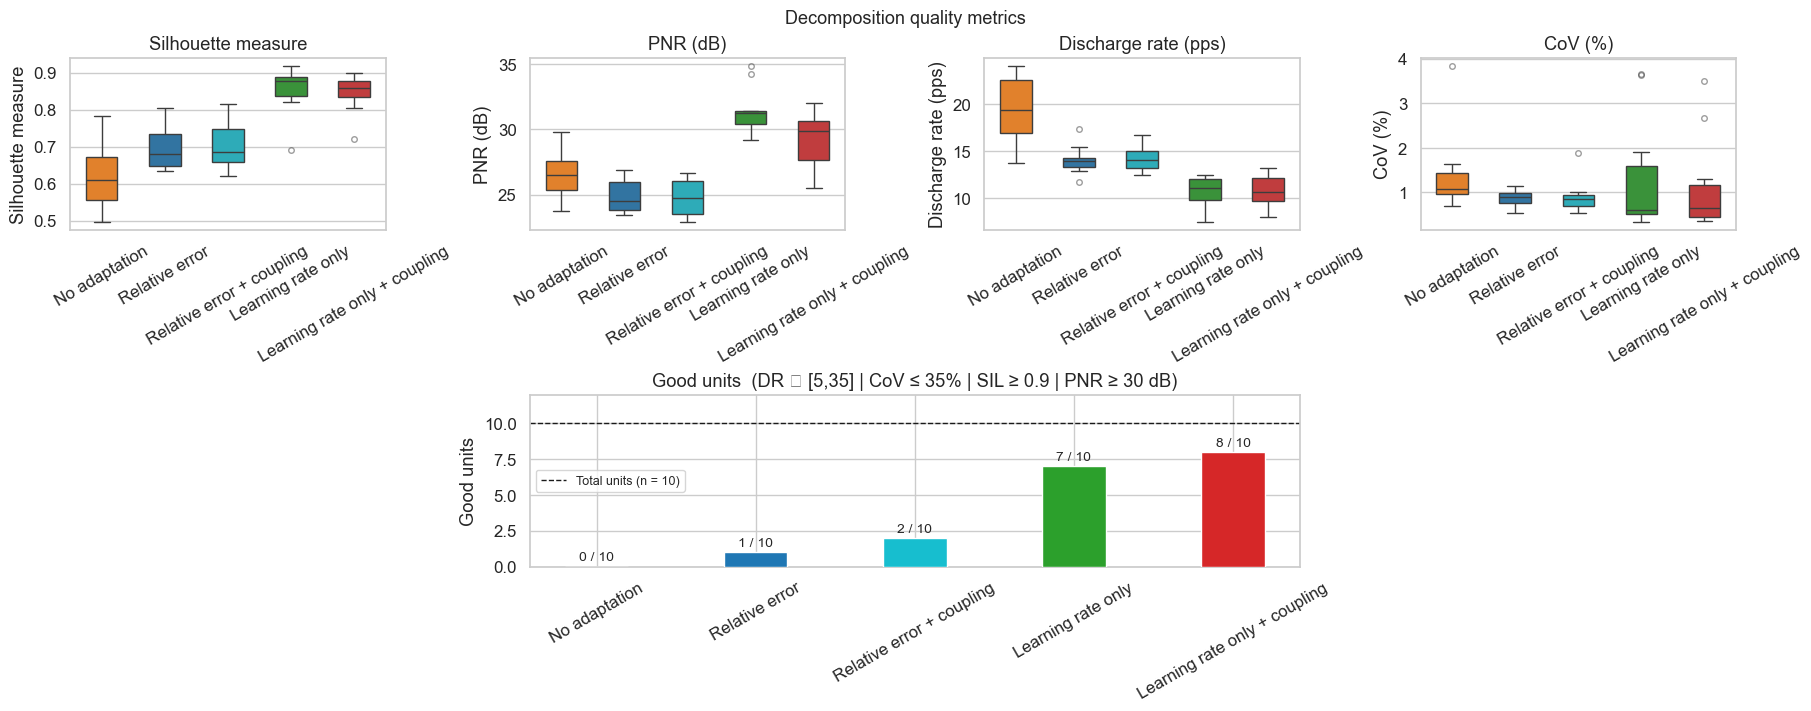

In [23]:
order   = cond_labels
palette = cond_colors

df_all['condition'] = pd.Categorical(df_all['condition'], categories=order, ordered=True)

fig = plt.figure(figsize=(18, 7), layout='constrained')
gs  = fig.add_gridspec(2, 4)
ax_sil = fig.add_subplot(gs[0, 0])
ax_pnr = fig.add_subplot(gs[0, 1])
ax_dr  = fig.add_subplot(gs[0, 2])
ax_cov = fig.add_subplot(gs[0, 3])
ax_bar = fig.add_subplot(gs[1, 1:3])

for ax, col, ylabel in [
    (ax_sil, 'SIL',      'Silhouette measure'),
    (ax_pnr, 'PNR (dB)', 'PNR (dB)'),
    (ax_dr,  'DR (pps)', 'Discharge rate (pps)'),
    (ax_cov, 'CoV (%)',  'CoV (%)'),
]:
    sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
                width=0.5, flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=ax)
    ax.set(xlabel='', ylabel=ylabel, title=ylabel)
    ax.tick_params(axis='x', rotation=30)

good_counts = df_all.groupby('condition', observed=True)['good'].sum().reindex(order)
bars = ax_bar.bar(order, good_counts.values,
                  color=[palette[c] for c in order], width=0.4, zorder=3)
ax_bar.axhline(n_total, color='k', linestyle='--', linewidth=1,
               label=f'Total units (n = {n_total})')
ax_bar.set(ylabel='Good units', ylim=(0, n_total + 2),
           title='Good units  (DR ∈ [5,35] | CoV ≤ 35% | SIL ≥ 0.9 | PNR ≥ 30 dB)')
ax_bar.legend(fontsize=9)
ax_bar.tick_params(axis='x', rotation=30)
for bar, count in zip(bars, good_counts.values):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, count + 0.2,
                f'{int(count)} / {n_total}', ha='center', va='bottom', fontsize=10)
plt.suptitle('Decomposition quality metrics', fontsize=13)
plt.show()


## 10. Coupling effect summary

Isolates the effect of `wh_b_coupling` under each update rule by comparing each
condition directly against its coupling-enabled counterpart. No ground-truth spike
trains are available for this real recording, so (unlike `sim_10`) this uses good-unit
counts only, without a rate-of-agreement comparison.


In [24]:
pairs = [
    ('Relative error', 'Relative error + coupling'),
    ('Learning rate only', 'Learning rate only + coupling'),
]

summary_rows = []
for base, coupled in pairs:
    good_base    = int(df_all[df_all['condition'] == base]['good'].sum())
    good_coupled = int(df_all[df_all['condition'] == coupled]['good'].sum())
    summary_rows.append({
        'lr_alone':                   base == 'Learning rate only',
        'condition':                  base,
        'good units (no coupling)':   good_base,
        'good units (coupling)':      good_coupled,
        'Δ good units':               good_coupled - good_base,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,lr_alone,condition,good units (no coupling),good units (coupling),Δ good units
0,False,Relative error,1,2,1
1,True,Learning rate only,7,8,1


## 11. Save results

In [25]:
df_all.to_csv(RESULTS_DIR / 'quality_metrics.csv', index=False)
summary_df.to_csv(RESULTS_DIR / 'coupling_summary.csv', index=False)

config_summary = {
    'subj': SUBJ, 'loc': LOC, 'task': TASK,
    'lr_v_lr_alone': LR_V_LR_ALONE, 'lr_v_rel_err': LR_V_REL_ERR, 'sv_learning_rate': LR_B_REL_ERR,
    'safety_clip_multiplier': SAFETY_CLIP,
    'n_units': n_units, 'total_units_iso0': total_units,
}
with open(RESULTS_DIR / 'config_summary.json', 'w') as f:
    json.dump(config_summary, f, indent=2)

print(f'Saved quality metrics, coupling summary, and config → {RESULTS_DIR}')


Saved quality metrics, coupling summary, and config → C:\Users\Irene\Documents\work_local\decomposition\data\processed\adapt_opt_results\sub1_forearm_staircase_flx_1_thumb_15MVC\kl_to_identity_lr_fixed
